In [35]:
from shapely import geometry
from pystac_client import Client
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import xarray as xr
from distributed import LocalCluster

Setup


In [36]:
# Create local processing cluster
cluster = LocalCluster()
client = cluster.get_client()

harz_boundaries = gpd.read_file("../resources/Nationalpark_Harz_boundaries.geojson")
bbox = harz_boundaries.geometry.values[0].bounds
#bbox = [10.633501, 51.611195, 10.787234, 51.698098]

bbox_polygon = geometry.box(*bbox)
polygon = gpd.GeoDataFrame(index=[0], crs="epsg:4326", geometry=[bbox_polygon])

epsg = 32632  # Sentinel-2 data CRS known a priori
bbox_reproj = polygon.to_crs("epsg:" + str(epsg)).geometry.values[0].bounds


catalog = Client.open("https://stac.core.eopf.eodc.eu")

D:\Workspace\harz-deforestation-eopf\.venv\Lib\site-packages\distributed\node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 64012 instead
  warnings.warn(
C:\Users\janph\AppData\Local\Programs\Python\Python312\Lib\contextlib.py:144: UserWarning: Creating scratch directories is taking a surprisingly long time. (1.04s) This is often due to running workers on a network file system. Consider specifying a local-directory to point workers to write scratch data to a local disk.
  next(self.gen)


In [37]:
def get_item_for_year(year):
    results = catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=bbox,
        datetime=[f"{year}-01-01", f"{year}-12-31"],
        query={"eo:cloud_cover": {"lt": 30}},  # optional filter
    )
    items = results.item_collection()
    if not items:
        return None

    # pick least cloudy item
    return min(items, key=lambda x: x.properties.get("eo:cloud_cover", 999))

In [38]:

years = range(2019, 2026)

items = [
    item for year in years
    if (item := get_item_for_year(year)) is not None
]
sr_datasets = []

for item in items:
    # Open SR_20m asset for this item
    ds = xr.open_dataset(item.assets["SR_10m"].href, engine="eopf-zarr", chunks={}, decode_timedelta=True)

    # Expand a time dimension using the item's timestamp
    ds = ds.expand_dims(time=pd.to_datetime([item.datetime]).tz_localize(None))

    sr_datasets.append(ds)

# Combine all items into one Dataset along time
r10m = xr.concat(sr_datasets, dim="time", join="outer")
r10m

<xarray.Dataset> Size: 44GB
Dimensions:      (time: 6, y: 10980, x: 20982)
Coordinates:
  * time         (time) datetime64[ns] 48B 2019-06-29T10:30:31.024000 ... 202...
  * y            (y) int64 88kB 5800015 5800005 5799995 ... 5690235 5690225
  * x            (x) int64 168kB 499985 499995 500005 ... 709775 709785 709795
    spatial_ref  int64 8B 0
Data variables:
    b02          (time, y, x) float64 11GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b03          (time, y, x) float64 11GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b04          (time, y, x) float64 11GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>
    b08          (time, y, x) float64 11GB dask.array<chunksize=(1, 1830, 1830), meta=np.ndarray>

In [39]:
import xarray as xr
import zarr
import dask.array as da
import pandas as pd

items = [
    item for year in years
    if (item := get_item_for_year(year)) is not None
]
sr_datasets = []


for item in items:
    # ------------------------------------------------------------------
    # 1. Open SR_20m
    # ------------------------------------------------------------------
    ds = xr.open_dataset(
        item.assets["SR_20m"].href,
        engine="eopf-zarr",
        chunks={}
    )

    # ------------------------------------------------------------------
    # 2. Open SCL_20m as a Dask-backed DataArray
    # ------------------------------------------------------------------
    scl_z = zarr.open(item.assets["SCL_20m"].href, mode="r")
    scl_da = xr.DataArray(
        da.from_array(scl_z, chunks=scl_z.chunks),
        dims=("y", "x"),
        name="scl"
    )

    # ------------------------------------------------------------------
    # 3. Add SCL as a new variable to the dataset
    # ------------------------------------------------------------------
    ds = ds.assign(scl=scl_da)

    # ------------------------------------------------------------------
    # 4. Add time dimension consistent with SR dataset
    # ------------------------------------------------------------------
    ds = ds.expand_dims(time=[pd.to_datetime(item.datetime).tz_localize(None)])

    sr_datasets.append(ds)

# ----------------------------------------------------------------------
# 5. Combine all datasets into a single time stack
# ----------------------------------------------------------------------
r20m_mask_l2a_classification = xr.concat(sr_datasets, dim="time", join="outer")
r20m_mask_l2a_classification

<xarray.Dataset> Size: 29GB
Dimensions:      (time: 6, y: 5490, x: 10491)
Coordinates:
  * time         (time) datetime64[ns] 48B 2019-06-29T10:30:31.024000 ... 202...
  * y            (y) int64 44kB 5800010 5799990 5799970 ... 5690250 5690230
  * x            (x) int64 84kB 499990 500010 500030 ... 709750 709770 709790
    spatial_ref  int64 8B 0
Data variables:
    b01          (time, y, x) float64 3GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b02          (time, y, x) float64 3GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b03          (time, y, x) float64 3GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b04          (time, y, x) float64 3GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b05          (time, y, x) float64 3GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b06          (time, y, x) float64 3GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b07          (time, y, x) float64 3GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b11          (time, y, x) float64 3GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b12          (time, y, x) float64 3GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    b8a          (time, y, x) float64 3GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>
    scl          (time, y, x) float32 1GB dask.array<chunksize=(1, 915, 915), meta=np.ndarray>

In [40]:
factor = 10
r100m = r10m.coarsen(x=factor, y=factor, boundary="trim").mean()
r100m.sel()

<xarray.Dataset> Size: 442MB
Dimensions:      (time: 6, y: 1098, x: 2098)
Coordinates:
  * time         (time) datetime64[ns] 48B 2019-06-29T10:30:31.024000 ... 202...
  * y            (y) float64 9kB 5.8e+06 5.8e+06 5.8e+06 ... 5.69e+06 5.69e+06
  * x            (x) float64 17kB 5e+05 5.001e+05 ... 7.096e+05 7.097e+05
    spatial_ref  int64 8B 0
Data variables:
    b02          (time, y, x) float64 111MB dask.array<chunksize=(1, 183, 183), meta=np.ndarray>
    b03          (time, y, x) float64 111MB dask.array<chunksize=(1, 183, 183), meta=np.ndarray>
    b04          (time, y, x) float64 111MB dask.array<chunksize=(1, 183, 183), meta=np.ndarray>
    b08          (time, y, x) float64 111MB dask.array<chunksize=(1, 183, 183), meta=np.ndarray>

In [41]:

target_chunks = {dim: ch[0] for dim, ch in zip(r100m["b02"].dims, r100m["b02"].chunks)}

# Interpolate and rechunk the SCL layer
scl_100m = (
    r20m_mask_l2a_classification.scl
    .chunk({"x": -1, "y": -1})  # merge chunks along x and y for interpolation
    .interp(x=r100m["x"], y=r100m["y"], method="nearest")
    .chunk(target_chunks)        # apply target chunks from r100m
)
# TODO: Why not coarse this aswell? Is it because we have to interpolate anyhow, because of resolution?
scl_100m

<xarray.DataArray 'scl' (time: 6, y: 1098, x: 2098)> Size: 55MB
dask.array<rechunk-merge, shape=(6, 1098, 2098), dtype=float32, chunksize=(1, 183, 183), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 48B 2019-06-29T10:30:31.024000 ... 202...
  * y            (y) float64 9kB 5.8e+06 5.8e+06 5.8e+06 ... 5.69e+06 5.69e+06
  * x            (x) float64 17kB 5e+05 5.001e+05 ... 7.096e+05 7.097e+05
    spatial_ref  int64 8B 0

In [42]:
def validate_scl(scl):
    invalid = [0, 1, 3, 7, 8, 9, 10]  # NO_DATA, SATURATED, CLOUD, etc.
    return ~scl.isin(invalid)


valid_mask = validate_scl(scl_100m)
valid_r100m = r100m.where(valid_mask) # Applying the mask
valid_mask

<xarray.DataArray 'scl' (time: 6, y: 1098, x: 2098)> Size: 14MB
dask.array<invert, shape=(6, 1098, 2098), dtype=bool, chunksize=(1, 183, 183), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 48B 2019-06-29T10:30:31.024000 ... 202...
  * y            (y) float64 9kB 5.8e+06 5.8e+06 5.8e+06 ... 5.69e+06 5.69e+06
  * x            (x) float64 17kB 5e+05 5.001e+05 ... 7.096e+05 7.097e+05
    spatial_ref  int64 8B 0

In [43]:
valid_r100m["b04"].attrs["_eopf_attrs"]["scale_factor"]


0.0001

In [44]:
valid_r100m["b08"].attrs["_eopf_attrs"]["add_offset"]

-0.1

In [45]:
from datetime import datetime

# Stack bands and NDVI, scale to match Sentinel Hub
# Not sure if we need to concat in this way? can keep it as data arrays in the dataset may be here??
scale = valid_r100m["b04"].attrs["_eopf_attrs"]["scale_factor"]
offset = valid_r100m["b08"].attrs["_eopf_attrs"]["add_offset"]
reflectances_r100m = (valid_r100m * scale) + offset

b08 = reflectances_r100m["b08"]
b04 = reflectances_r100m["b04"]
ndvi = (b08 - b04) / (b08 + b04)  # Per-pixel NDVI


reflectances_r100m["ndvi"] = ndvi

x_slice = slice(bbox_reproj[0], bbox_reproj[2])  # ~100 pixels
y_slice = slice(bbox_reproj[3], bbox_reproj[1])  # ~100 pixels

cloudless_bands_ndvi = reflectances_r100m.sel(
    time=datetime(2018, 6, 4), method="nearest"
)

region = cloudless_bands_ndvi.sel(x=x_slice, y=y_slice).chunk(
    {"y": "auto", "x": "auto"}
)

rgb = region[["b04", "b03", "b02"]].to_dataarray(dim="bands")
#rgb = (rgb - 0.02) / (0.35 - 0.02)  # Stretch 0.02-0.35 to 0-1
#rgb = rgb.clip(0, 1).compute()

ndvi = region["ndvi"].compute()

yearly_ds = (
    reflectances_r100m.sel(x=x_slice, y=y_slice)
    .groupby("time.year")
    .mean(dim="time", skipna=True)
)
yearly_ds

<xarray.Dataset> Size: 15MB
Dimensions:      (year: 6, y: 262, x: 232)
Coordinates:
  * year         (year) int64 48B 2019 2020 2021 2022 2023 2025
  * y            (y) float64 2kB 5.751e+06 5.751e+06 ... 5.725e+06 5.725e+06
  * x            (x) float64 2kB 5.908e+05 5.909e+05 ... 6.138e+05 6.139e+05
    spatial_ref  int64 8B 0
Data variables:
    b02          (year, y, x) float64 3MB dask.array<chunksize=(1, 61, 7), meta=np.ndarray>
    b03          (year, y, x) float64 3MB dask.array<chunksize=(1, 61, 7), meta=np.ndarray>
    b04          (year, y, x) float64 3MB dask.array<chunksize=(1, 61, 7), meta=np.ndarray>
    b08          (year, y, x) float64 3MB dask.array<chunksize=(1, 61, 7), meta=np.ndarray>
    ndvi         (year, y, x) float64 3MB dask.array<chunksize=(1, 61, 7), meta=np.ndarray>

In [46]:
yearly_ds.ndvi.attrs

{'_eopf_attrs': {'add_offset': -0.1,
  'coordinates': ['x', 'y'],
  'dimensions': ['y', 'x'],
  'fill_value': 0,
  'scale_factor': 0.0001,
  'units': 'digital_counts'},
 'dtype': '<u2',
 'fill_value': 0,
 'proj:bbox': [600000.0, 5690220.0, 709800.0, 5800020.0],
 'proj:epsg': 32632,
 'proj:shape': [10980, 10980],
 'proj:transform': [10.0, 0.0, 600000.0, 0.0, -10.0, 5800020.0, 0.0, 0.0, 1.0],
 'proj:wkt2': 'PROJCS["WGS 84 / UTM zone 32N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",9],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","326

In [47]:
ndvi.min().item(), ndvi.max().item(), ndvi.mean().item()

(-0.00026281144580252803, 2.354449908104011e-05, -0.00010879461093768749)

In [48]:
ndvi.data

array([[            nan,             nan,             nan, ...,
        -1.03647847e-04, -8.86591602e-05, -8.89463001e-05],
       [            nan,             nan,             nan, ...,
        -1.12337996e-04, -1.14328549e-04, -1.02214813e-04],
       [            nan,             nan,             nan, ...,
        -1.43676290e-04, -1.12467269e-04, -1.45706539e-04],
       ...,
       [            nan,             nan,             nan, ...,
        -7.07505406e-05, -7.01811929e-05, -1.11789557e-04],
       [            nan,             nan,             nan, ...,
        -8.60874851e-05, -7.47621679e-05, -1.04139723e-04],
       [            nan,             nan,             nan, ...,
        -9.35379331e-05, -9.05064243e-05, -9.16403792e-05]],
      shape=(262, 232))

In [49]:
def plot_rgb_ndvi(dset, year, x_slice, y_slice):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Date - " + str(year) + "\n")

    # First subplot
    rgb = dset[["b04", "b03", "b02"]].to_dataarray(dim="bands")
    rgb = (rgb - 0.02) / (0.35 - 0.02)  # Stretch 0.02-0.35 to 0-1
    rgb = rgb.clip(0, 1)  # Clip to valid range
    rgb.plot.imshow(
        ax=ax1,
        rgb="bands",
        extent=(x_slice.start, x_slice.stop, y_slice.start, y_slice.stop),
    )
    ax1.set_title("RGB (Enhanced)")

    # Second plot
    ndvi_plot = dset["ndvi"].plot(
        ax=ax2, cmap="Greens", vmin=-1, vmax=1, add_colorbar=False
    )
    ax2.set_title("NDVI")

    # Add color bar on the right
    fig.subplots_adjust(right=0.8)
    cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
    fig.colorbar(ndvi_plot, cax=cbar_ax)

In [50]:
year = 2020
region = yearly_ds.sel(year=year)

region

<xarray.Dataset> Size: 2MB
Dimensions:      (y: 262, x: 232)
Coordinates:
  * y            (y) float64 2kB 5.751e+06 5.751e+06 ... 5.725e+06 5.725e+06
  * x            (x) float64 2kB 5.908e+05 5.909e+05 ... 6.138e+05 6.139e+05
    spatial_ref  int64 8B 0
    year         int64 8B 2020
Data variables:
    b02          (y, x) float64 486kB dask.array<chunksize=(61, 7), meta=np.ndarray>
    b03          (y, x) float64 486kB dask.array<chunksize=(61, 7), meta=np.ndarray>
    b04          (y, x) float64 486kB dask.array<chunksize=(61, 7), meta=np.ndarray>
    b08          (y, x) float64 486kB dask.array<chunksize=(61, 7), meta=np.ndarray>
    ndvi         (y, x) float64 486kB dask.array<chunksize=(61, 7), meta=np.ndarray>

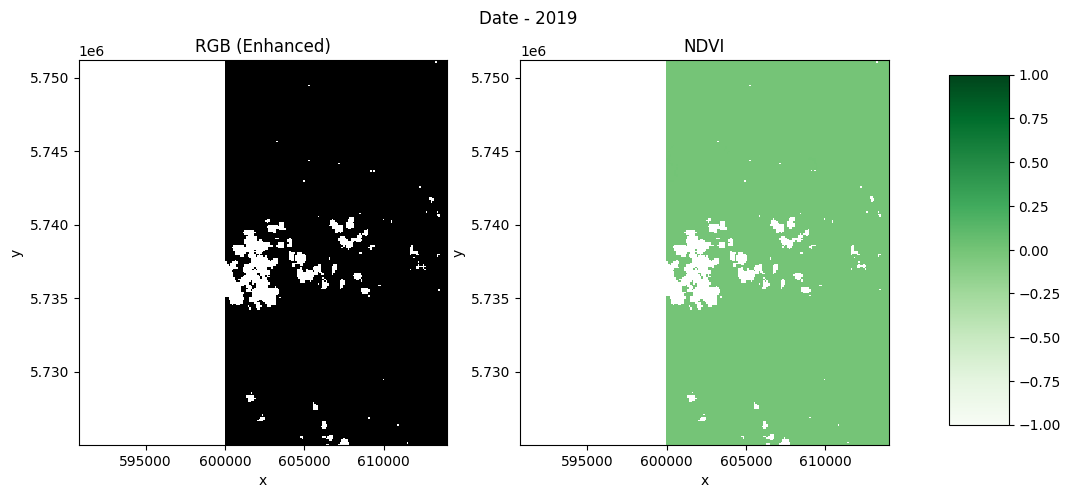

In [51]:
plot_rgb_ndvi(region, 2019, x_slice, y_slice)

In [52]:
yearly_ds

<xarray.Dataset> Size: 15MB
Dimensions:      (year: 6, y: 262, x: 232)
Coordinates:
  * year         (year) int64 48B 2019 2020 2021 2022 2023 2025
  * y            (y) float64 2kB 5.751e+06 5.751e+06 ... 5.725e+06 5.725e+06
  * x            (x) float64 2kB 5.908e+05 5.909e+05 ... 6.138e+05 6.139e+05
    spatial_ref  int64 8B 0
Data variables:
    b02          (year, y, x) float64 3MB dask.array<chunksize=(1, 61, 7), meta=np.ndarray>
    b03          (year, y, x) float64 3MB dask.array<chunksize=(1, 61, 7), meta=np.ndarray>
    b04          (year, y, x) float64 3MB dask.array<chunksize=(1, 61, 7), meta=np.ndarray>
    b08          (year, y, x) float64 3MB dask.array<chunksize=(1, 61, 7), meta=np.ndarray>
    ndvi         (year, y, x) float64 3MB dask.array<chunksize=(1, 61, 7), meta=np.ndarray>

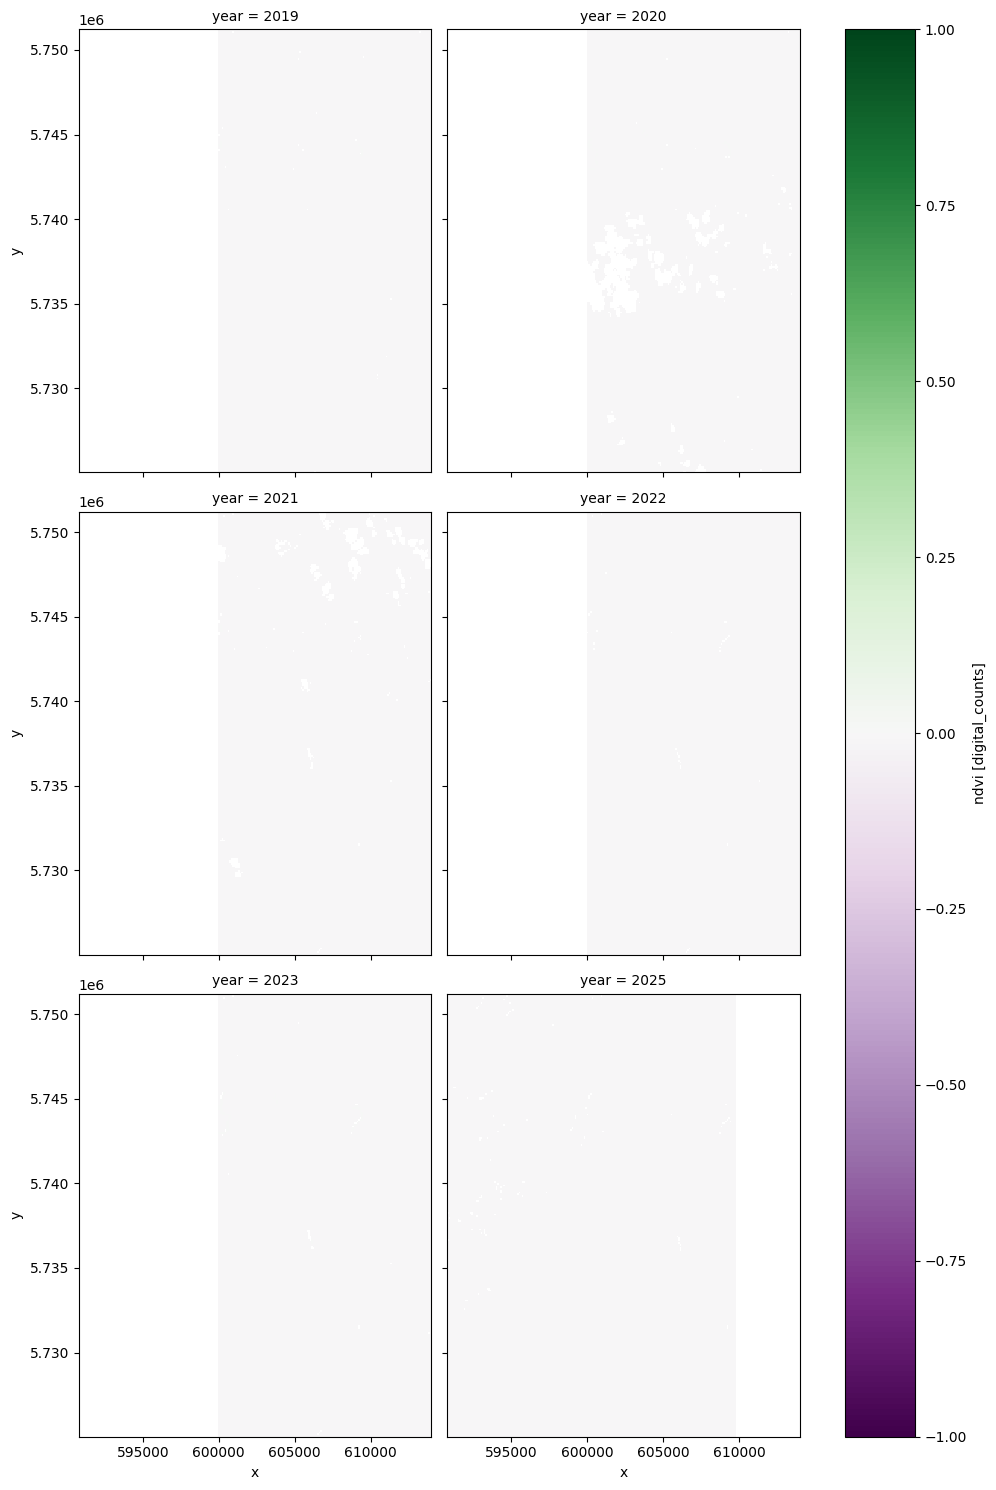

In [53]:
ndvi_yearly = yearly_ds["ndvi"].sel(x=x_slice, y=y_slice).sel(
    year=slice(2018, 2025)
)

ndvi_yearly.plot(
    cmap="PRGn", x="x", y="y", col="year", col_wrap=2, vmin=-1, vmax=1, figsize=(10, 15)
)

In [54]:
yearly_ds.ndvi.values

array([[[            nan,             nan,             nan, ...,
         -1.03647847e-04, -8.86591602e-05, -8.89463001e-05],
        [            nan,             nan,             nan, ...,
         -1.12337996e-04, -1.14328549e-04, -1.02214813e-04],
        [            nan,             nan,             nan, ...,
         -1.43676290e-04, -1.12467269e-04, -1.45706539e-04],
        ...,
        [            nan,             nan,             nan, ...,
         -7.07505406e-05, -7.01811929e-05, -1.11789557e-04],
        [            nan,             nan,             nan, ...,
         -8.60874851e-05, -7.47621679e-05, -1.04139723e-04],
        [            nan,             nan,             nan, ...,
         -9.35379331e-05, -9.05064243e-05, -9.16403792e-05]],

       [[            nan,             nan,             nan, ...,
         -8.20387188e-05, -5.51767200e-05, -6.21841237e-05],
        [            nan,             nan,             nan, ...,
         -8.05123959e-05, -7.37514764e

In [55]:
import numpy as np
yearly_ds.ndvi.load()
yearly_ds["FOREST"] = yearly_ds.ndvi > 0.7

def to_km2(dataarray, resolution):
    # Calculate forest area
    return dataarray * np.prod(list(resolution)) / 1e6


resolution = (100, 100)
forest_pixels = yearly_ds.sel(x=x_slice, y=y_slice).FOREST.sum(["x", "y"])
forest_area_km2 = to_km2(forest_pixels, resolution)
forest_area_km2


<xarray.DataArray 'FOREST' (year: 6)> Size: 48B
array([0., 0., 0., 0., 0., 0.])
Coordinates:
  * year         (year) int64 48B 2019 2020 2021 2022 2023 2025
    spatial_ref  int64 8B 0
Attributes: (12)

In [56]:
yearly_ds["FOREST"]

forest_area_km2.load()


<xarray.DataArray 'FOREST' (year: 6)> Size: 48B
array([0., 0., 0., 0., 0., 0.])
Coordinates:
  * year         (year) int64 48B 2019 2020 2021 2022 2023 2025
    spatial_ref  int64 8B 0
Attributes: (12)

In [57]:
yearly_ds.ndvi

<xarray.DataArray 'ndvi' (year: 6, y: 262, x: 232)> Size: 3MB
array([[[            nan,             nan,             nan, ...,
         -1.03647847e-04, -8.86591602e-05, -8.89463001e-05],
        [            nan,             nan,             nan, ...,
         -1.12337996e-04, -1.14328549e-04, -1.02214813e-04],
        [            nan,             nan,             nan, ...,
         -1.43676290e-04, -1.12467269e-04, -1.45706539e-04],
        ...,
        [            nan,             nan,             nan, ...,
         -7.07505406e-05, -7.01811929e-05, -1.11789557e-04],
        [            nan,             nan,             nan, ...,
         -8.60874851e-05, -7.47621679e-05, -1.04139723e-04],
        [            nan,             nan,             nan, ...,
         -9.35379331e-05, -9.05064243e-05, -9.16403792e-05]],

       [[            nan,             nan,             nan, ...,
         -8.20387188e-05, -5.51767200e-05, -6.21841237e-05],
        [            nan,             nan,             nan, ...,
         -8.05123959e-05, -7.37514764e-05, -6.57487175e-05],
        [            nan,             nan,             nan, ...,
         -1.07754487e-04, -7.30942798e-05, -1.14336425e-04],
...
         -1.54902299e-04, -1.49578703e-04, -1.46645568e-04],
        [            nan,             nan,             nan, ...,
         -1.64616097e-04, -1.34788697e-04, -1.54835092e-04],
        [            nan,             nan,             nan, ...,
         -1.85402177e-04, -1.59955751e-04, -1.74226567e-04]],

       [[-1.04698132e-04, -1.29205370e-04, -1.31433990e-04, ...,
                     nan,             nan,             nan],
        [-1.28916349e-04, -1.33871242e-04, -1.22133305e-04, ...,
                     nan,             nan,             nan],
        [-1.39961189e-04, -1.34491720e-04, -1.23957954e-04, ...,
                     nan,             nan,             nan],
        ...,
        [-1.54178253e-04, -1.41709167e-04, -1.81796412e-04, ...,
                     nan,             nan,             nan],
        [-1.69468925e-04, -1.22265667e-04, -1.09880001e-04, ...,
                     nan,             nan,             nan],
        [-1.67847002e-04, -1.48949386e-04, -1.23389073e-04, ...,
                     nan,             nan,             nan]]],
      shape=(6, 262, 232))
Coordinates:
  * year         (year) int64 48B 2019 2020 2021 2022 2023 2025
  * y            (y) float64 2kB 5.751e+06 5.751e+06 ... 5.725e+06 5.725e+06
  * x            (x) float64 2kB 5.908e+05 5.909e+05 ... 6.138e+05 6.139e+05
    spatial_ref  int64 8B 0
Attributes: (12)

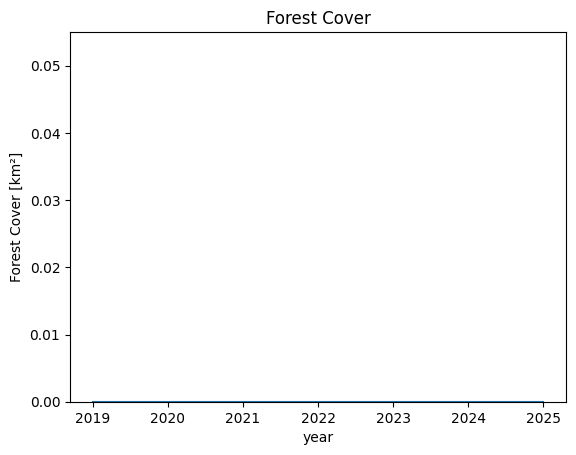

In [58]:

forest_area_km2.plot()

plt.title("Forest Cover")
plt.ylabel("Forest Cover [km²]")
plt.ylim(0);

In [59]:
forest_area_km2

<xarray.DataArray 'FOREST' (year: 6)> Size: 48B
array([0., 0., 0., 0., 0., 0.])
Coordinates:
  * year         (year) int64 48B 2019 2020 2021 2022 2023 2025
    spatial_ref  int64 8B 0
Attributes: (12)